Loading Word2Vec model...
Model Loaded!

========== Gender Bias (Career vs Family) ==========
WEAT Score: 0.5760747
Effect Size: 0.6290184
Interpretation: X is more associated with A.

========== Racial Bias (Pleasant vs Unpleasant) ==========
WEAT Score: -0.07668306
Effect Size: -0.32590735
Interpretation: Y is more associated with A.

========== Religious Bias (Pleasant vs Unpleasant) ==========
WEAT Score: 0.16131353
Effect Size: 1.240433
Interpretation: X is more associated with A.


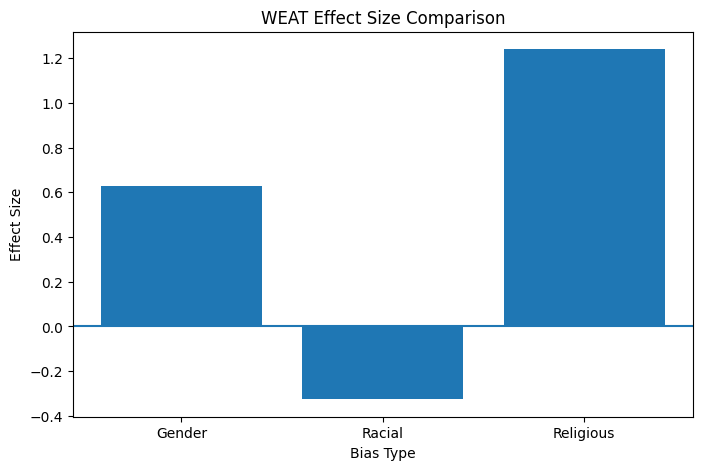

In [ ]:
# Install gensim
!pip install gensim

import numpy as np
import gensim
import gensim.downloader as api
import matplotlib.pyplot as plt

# Load pretrained Word2Vec model
print("Loading Word2Vec model...")
model = api.load("word2vec-google-news-300")
print("Model Loaded!")

# -------------------------------
# Helper Functions
# -------------------------------

def filter_vocab(words):
    return [w for w in words if w in model.key_to_index]

def association(w, A, B):
    mean_A = np.mean([model.similarity(w, a) for a in A])
    mean_B = np.mean([model.similarity(w, b) for b in B])
    return mean_A - mean_B

def weat_score(X, Y, A, B):
    score_X = np.sum([association(x, A, B) for x in X])
    score_Y = np.sum([association(y, A, B) for y in Y])
    return score_X - score_Y

def effect_size(X, Y, A, B):
    assoc_X = np.array([association(x, A, B) for x in X])
    assoc_Y = np.array([association(y, A, B) for y in Y])
    mean_diff = np.mean(assoc_X) - np.mean(assoc_Y)
    pooled_std = np.std(np.concatenate([assoc_X, assoc_Y]), ddof=1)
    return mean_diff / pooled_std

def run_weat(test_name, X, Y, A, B):

    X, Y = filter_vocab(X), filter_vocab(Y)
    A, B = filter_vocab(A), filter_vocab(B)

    weat = weat_score(X, Y, A, B)
    eff_size = effect_size(X, Y, A, B)

    print("\n==========", test_name, "==========")
    print("WEAT Score:", weat)
    print("Effect Size:", eff_size)

    if eff_size > 0:
        print("Interpretation: X is more associated with A.")
    elif eff_size < 0:
        print("Interpretation: Y is more associated with A.")
    else:
        print("Interpretation: No detectable bias.")

    return eff_size


# -------------------------------
# Word Sets
# -------------------------------

X_gender = ["man", "male", "boy", "brother", "he", "him", "his", "son"]
Y_gender = ["woman", "female", "girl", "sister", "she", "her", "hers", "daughter"]

A_career = ["career", "business", "office", "salary", "corporation",
            "professional", "management", "industry"]

B_family = ["family", "home", "children", "parent",
            "marriage", "wedding", "relatives", "house"]


X_race = ["european", "caucasian", "white"]
Y_race = ["african", "black"]

A_pleasant = ["joy", "love", "peace", "wonderful",
              "pleasure", "friend", "laughter"]

B_unpleasant = ["pain", "hate", "anger",
                "evil", "failure", "nasty", "awful"]


X_religion = ["christian", "church", "bible"]
Y_religion = ["muslim", "islam", "quran"]


# -------------------------------
# Run Tests
# -------------------------------

results = {}

results["Gender"] = run_weat(
    "Gender Bias (Career vs Family)",
    X_gender, Y_gender,
    A_career, B_family
)

results["Racial"] = run_weat(
    "Racial Bias (Pleasant vs Unpleasant)",
    X_race, Y_race,
    A_pleasant, B_unpleasant
)

results["Religious"] = run_weat(
    "Religious Bias (Pleasant vs Unpleasant)",
    X_religion, Y_religion,
    A_pleasant, B_unpleasant
)


# -------------------------------
# Plot Results
# -------------------------------

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.axhline(0)
plt.title("WEAT Effect Size Comparison")
plt.ylabel("Effect Size")
plt.xlabel("Bias Type")
plt.show()